# Food Delivery Orders-Exploratory Data Analysis


## 1. Project Introduction

### Project Scenario
A food delivery company processes thousands of orders across multiple cities, restaurant types, and cuisines. The company wants to understand order patterns, customer preferences, delivery performance, and customer satisfaction.

As a **Data Analyst**, your task is to perform **Exploratory Data Analysis (EDA)** on historical food delivery data and identify useful business insights.

### Project Objectives
- Understand the structure and quality of the data.
- Identify and handle missing values, duplicates, inconsistent values, and outliers.
- Understand ordering and spending patterns.
- Identify popular cuisines and restaurant types.
- Analyze trends across cities and time periods.
- Evaluate delivery performance.
- Study relationships among distance, delivery time, and customer ratings.
- Generate business insights and recommendations.

### Dataset Description
The dataset contains about **5,000 food delivery orders**.

| Column | Description |
|---|---|
| `Order_ID` | Unique identifier for each order |
| `Order_Date` | Date on which the order was placed |
| `Order_Time` | Time at which the order was placed |
| `Customer_ID` | Unique customer identifier |
| `City` | City where the order was placed |
| `Restaurant_Type` | Type of restaurant |
| `Cuisine` | Type of cuisine ordered |
| `Order_Value` | Value of the food order |
| `Delivery_Fee` | Delivery charge |
| `Payment_Method` | Payment method used |
| `Delivery_Time_Min` | Delivery time in minutes |
| `Distance_KM` | Restaurant-to-customer distance |
| `Customer_Rating` | Rating given by the customer |
| `Order_Status` | Final status of the order |

### EDA Workflow
**Understand → Assess Quality → Clean → Create Features → Analyze → Visualize → Interpret → Recommend**

# 2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3 Load the Dataset

In [3]:
df=pd.read_csv("food_delivery_orders_eda.csv")
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,City,Restaurant_Type,Cuisine,Order_Value,Delivery_Fee,Payment_Method,Delivery_Time_Min,Distance_KM,Customer_Rating,Order_Status
0,ORD103631,16-11-2025,22:42:30,C1467,Bangalore,Cloud Kitchen,Desserts,172.11,46.40,UPI,31.2,2.9,5.0,Delivered
1,ORD100840,08-09-2025,14:56:00,C1205,Bangalore,Cafe,Desserts,90.00,39.64,UPI,31.6,3.2,4.6,Delivered
2,ORD103690,26-01-2025,20:52:15,C1084,Chennai,Cafe,Biryani,299.69,45.51,Wallet,33.6,2.9,4.8,Delivered
3,ORD104690,21-02-2025,14:37:30,C1799,Kochi,Fast Food,Biryani,247.32,32.94,Debit Card,29.8,2.2,4.5,Delivered
4,ORD101595,12-02-2025,17:27:00,C1596,Hyderabad,Fast Food,South Indian,218.73,49.14,UPI,29.1,3.9,5.0,Delivered


# 4 Understanding the Dataset

## Display the first 5 rows

In [4]:
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,City,Restaurant_Type,Cuisine,Order_Value,Delivery_Fee,Payment_Method,Delivery_Time_Min,Distance_KM,Customer_Rating,Order_Status
0,ORD103631,16-11-2025,22:42:30,C1467,Bangalore,Cloud Kitchen,Desserts,172.11,46.40,UPI,31.2,2.9,5.0,Delivered
1,ORD100840,08-09-2025,14:56:00,C1205,Bangalore,Cafe,Desserts,90.00,39.64,UPI,31.6,3.2,4.6,Delivered
2,ORD103690,26-01-2025,20:52:15,C1084,Chennai,Cafe,Biryani,299.69,45.51,Wallet,33.6,2.9,4.8,Delivered
3,ORD104690,21-02-2025,14:37:30,C1799,Kochi,Fast Food,Biryani,247.32,32.94,Debit Card,29.8,2.2,4.5,Delivered
4,ORD101595,12-02-2025,17:27:00,C1596,Hyderabad,Fast Food,South Indian,218.73,49.14,UPI,29.1,3.9,5.0,Delivered


## Check the number of rows and columns

In [5]:
df.shape

(5000, 14)

## View Column names

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Time', 'Customer_ID', 'City',
       'Restaurant_Type', 'Cuisine', 'Order_Value', 'Delivery_Fee',
       'Payment_Method', 'Delivery_Time_Min', 'Distance_KM', 'Customer_Rating',
       'Order_Status'],
      dtype='str')

## Check datatype and non null values

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           5000 non-null   str    
 1   Order_Date         5000 non-null   str    
 2   Order_Time         5000 non-null   str    
 3   Customer_ID        5000 non-null   str    
 4   City               5000 non-null   str    
 5   Restaurant_Type    5000 non-null   str    
 6   Cuisine            4958 non-null   str    
 7   Order_Value        5000 non-null   float64
 8   Delivery_Fee       5000 non-null   float64
 9   Payment_Method     5000 non-null   str    
 10  Delivery_Time_Min  4677 non-null   float64
 11  Distance_KM        5000 non-null   float64
 12  Customer_Rating    4611 non-null   float64
 13  Order_Status       5000 non-null   str    
dtypes: float64(5), str(9)
memory usage: 547.0 KB


## Statistcal summary

In [8]:
df.describe()

,Order_Value,Delivery_Fee,Delivery_Time_Min,Distance_KM,Customer_Rating
count,5000.000000,5000.000000,4677.000000,5000.00000,4611.000000
mean,430.642108,40.056242,35.265640,4.25742,4.427239
std,332.477755,15.788187,12.363382,2.54374,0.399109
min,90.000000,0.000000,12.000000,0.50000,2.700000
25%,267.267500,29.347500,27.200000,2.40000,4.200000
50%,372.580000,38.605000,34.300000,3.70000,4.500000
75%,513.367500,49.467500,42.000000,5.60000,4.700000
max,7777.620000,110.540000,172.100000,15.00000,5.000000


## Intial Observations


The dataset contains 5000 rows and 14 columns, with each row representing a food delivery order.
The dataset contains combinations of identifier,categorical,numerical,date related columns.
Order_ID and Customer_ID are indentifiers.
Order_Date and Order_Time are date and time related columns.
City,Resturant_Type,Cuisine,Payment_Method are categorical columns.
Numerical information includes Order_Value, Delivery_Fee, Delivery_Time_Min, Distance_KM, and Customer_Rating.
Some columns contain missing values, particularly Cuisine, Delivery_Time_Min, and Customer_Rating.


# 5 Data Quality Assessment

## Check Missing Values

In [9]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Order_Time             0
Customer_ID            0
City                   0
Restaurant_Type        0
Cuisine               42
Order_Value            0
Delivery_Fee           0
Payment_Method         0
Delivery_Time_Min    323
Distance_KM            0
Customer_Rating      389
Order_Status           0
dtype: int64

##  Missing Value percentage

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Order_ID             0.00
Order_Date           0.00
Order_Time           0.00
Customer_ID          0.00
City                 0.00
Restaurant_Type      0.00
Cuisine              0.84
Order_Value          0.00
Delivery_Fee         0.00
Payment_Method       0.00
Delivery_Time_Min    6.46
Distance_KM          0.00
Customer_Rating      7.78
Order_Status         0.00
dtype: float64

## Check Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(12)

## Inspect categorical values

In [12]:
categorical_columns = ["City", "Restaurant_Type", "Cuisine", "Payment_Method", "Order_Status"]

for column in categorical_columns:
    print("\n")
    print(df[column].value_counts(dropna=False))



City
Bangalore      1524
Mumbai         1048
Hyderabad      1006
Chennai         867
Kochi           543
 Bangalore        5
 Mumbai           3
 Hyderabad        2
 Chennai          1
 Kochi            1
Name: count, dtype: int64


Restaurant_Type
Fast Food        1432
Cloud Kitchen    1198
Casual Dining    1194
Cafe              792
Fine Dining       384
Name: count, dtype: int64


Cuisine
North Indian    910
South Indian    884
Biryani         858
Chinese         722
Fast Food       554
Italian         405
Desserts        360
Continental     265
NaN              42
Name: count, dtype: int64


Payment_Method
UPI            2206
Credit Card     917
Cash            868
Debit Card      572
Wallet          429
upi               7
Upi               1
Name: count, dtype: int64


Order_Status
Delivered    4620
Cancelled     287
Refunded       93
Name: count, dtype: int64


## Data Quality Observations

Cuisine has 42 missing values,<br>
Delivery_time_min has 323 missing values,<br>
Customer_rating has 389 missing values,<br>
There are 12 duplicates in the dataset,<br>
There is captilization and whitespace issue in Payment_Method and City

# 6 Data Cleaning

## Remove duplicate records

In [13]:
df=df.drop_duplicates()
df.shape

(4988, 14)

## Remove Extra Space from Text columns

In [14]:
text_columns = ["City", "Restaurant_Type", "Cuisine", "Payment_Method", "Order_Status"]

for column in text_columns:
    df[column] = df[column].str.strip()

In [15]:
df["City"].value_counts()


City
Bangalore    1525
Mumbai       1047
Hyderabad    1005
Chennai       868
Kochi         543
Name: count, dtype: int64

## Handling captilization issue with payment method column

In [16]:
df["Payment_Method"]=df["Payment_Method"].replace("upi","UPI")

In [17]:
df["Payment_Method"]=df["Payment_Method"].replace("Upi","UPI")

In [18]:
df["Payment_Method"].value_counts()

Payment_Method
UPI            2208
Credit Card     915
Cash            866
Debit Card      571
Wallet          428
Name: count, dtype: int64

## Handle Missing Cuisine Value

In [19]:
df["Cuisine"]=df["Cuisine"].fillna("Unknown")

In [20]:
df["Cuisine"].isnull().sum()

np.int64(0)

In [21]:
df["Cuisine"].value_counts()

Cuisine
North Indian    908
South Indian    879
Biryani         857
Chinese         719
Fast Food       554
Italian         404
Desserts        360
Continental     265
Unknown          42
Name: count, dtype: int64

## Handle missing values in delivery time and rating

In [22]:
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,City,Restaurant_Type,Cuisine,Order_Value,Delivery_Fee,Payment_Method,Delivery_Time_Min,Distance_KM,Customer_Rating,Order_Status
0,ORD103631,16-11-2025,22:42:30,C1467,Bangalore,Cloud Kitchen,Desserts,172.11,46.40,UPI,31.2,2.9,5.0,Delivered
1,ORD100840,08-09-2025,14:56:00,C1205,Bangalore,Cafe,Desserts,90.00,39.64,UPI,31.6,3.2,4.6,Delivered
2,ORD103690,26-01-2025,20:52:15,C1084,Chennai,Cafe,Biryani,299.69,45.51,Wallet,33.6,2.9,4.8,Delivered
3,ORD104690,21-02-2025,14:37:30,C1799,Kochi,Fast Food,Biryani,247.32,32.94,Debit Card,29.8,2.2,4.5,Delivered
4,ORD101595,12-02-2025,17:27:00,C1596,Hyderabad,Fast Food,South Indian,218.73,49.14,UPI,29.1,3.9,5.0,Delivered


In [23]:
df[df["Delivery_Time_Min"].isnull()]["Order_Status"].value_counts()

Order_Status
Cancelled    286
Delivered     36
Name: count, dtype: int64

In [24]:
df[df["Customer_Rating"].isnull()]["Order_Status"].value_counts()

Order_Status
Cancelled    286
Delivered    102
Name: count, dtype: int64

In [25]:
delivery_median=df["Delivery_Time_Min"].median()

In [26]:
df.loc[(df["Order_Status"] == "Delivered") & (df["Delivery_Time_Min"].isnull()),
    "Delivery_Time_Min"] = delivery_median

In [27]:
df["Delivery_Time_Min"].value_counts()

Delivery_Time_Min
12.00    48
34.25    36
28.70    28
34.50    28
30.10    25
         ..
58.50     1
84.20     1
68.40     1
63.20     1
59.80     1
Name: count, Length: 562, dtype: int64

## Recheck the clean data

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 4988 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           4988 non-null   str    
 1   Order_Date         4988 non-null   str    
 2   Order_Time         4988 non-null   str    
 3   Customer_ID        4988 non-null   str    
 4   City               4988 non-null   str    
 5   Restaurant_Type    4988 non-null   str    
 6   Cuisine            4988 non-null   str    
 7   Order_Value        4988 non-null   float64
 8   Delivery_Fee       4988 non-null   float64
 9   Payment_Method     4988 non-null   str    
 10  Delivery_Time_Min  4702 non-null   float64
 11  Distance_KM        4988 non-null   float64
 12  Customer_Rating    4600 non-null   float64
 13  Order_Status       4988 non-null   str    
dtypes: float64(5), str(9)
memory usage: 584.5 KB


In [29]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Order_Time             0
Customer_ID            0
City                   0
Restaurant_Type        0
Cuisine                0
Order_Value            0
Delivery_Fee           0
Payment_Method         0
Delivery_Time_Min    286
Distance_KM            0
Customer_Rating      388
Order_Status           0
dtype: int64

## Feature Engineering

In [30]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

C:\Users\HP\AppData\Local\Temp\ipykernel_6384\544640231.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"]=pd.to_datetime(df["Order_Date"])


In [31]:
df["Order_Date"].dtype

dtype('<M8[us]')

## Create Month Column

In [32]:
df["Month"]=df["Order_Date"].dt.month_name()
df["Month"].head()

0     November
1    September
2      January
3     February
4     February
Name: Month, dtype: str

In [33]:
df["Day"]=df["Order_Date"].dt.day_name()
df["Day"].head()

0       Sunday
1       Monday
2       Sunday
3       Friday
4    Wednesday
Name: Day, dtype: str

In [34]:
df["Order_Time"]=pd.to_datetime(df["Order_Time"])

C:\Users\HP\AppData\Local\Temp\ipykernel_6384\21909411.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order_Time"]=pd.to_datetime(df["Order_Time"])


In [35]:
df["Order_Hour"]=df["Order_Time"].dt.hour
df["Order_Hour"].head()

0    22
1    14
2    20
3    14
4    17
Name: Order_Hour, dtype: int32

In [36]:
def order_period(hour):
    if 6 <= hour < 11:
        return "Morning"
    elif 11 <= hour < 15:
        return "Lunch"
    elif 15 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 23:
        return "Dinner"
    else:
        return "Late Night"

df["Order_Period"] = df["Order_Hour"].apply(order_period)
df["Order_Period"].value_counts()

Order_Period
Dinner        2253
Lunch         1442
Afternoon      657
Morning        368
Late Night     268
Name: count, dtype: int64

# Univariate analysis

## Distribution Of Order Value

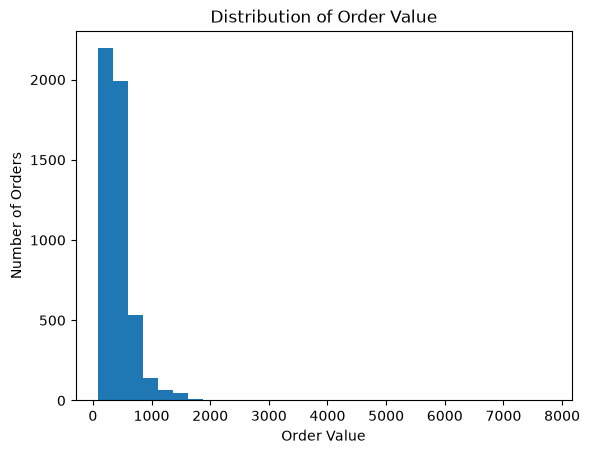

In [37]:
plt.hist(df["Order_Value"], bins=30)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.show()



**Observation:**<br>
Most of the Orders are below 1000.<br>
The number of orders decreased considerable when the order value increases.<br>

## Distribution of Delivery_Time_Min

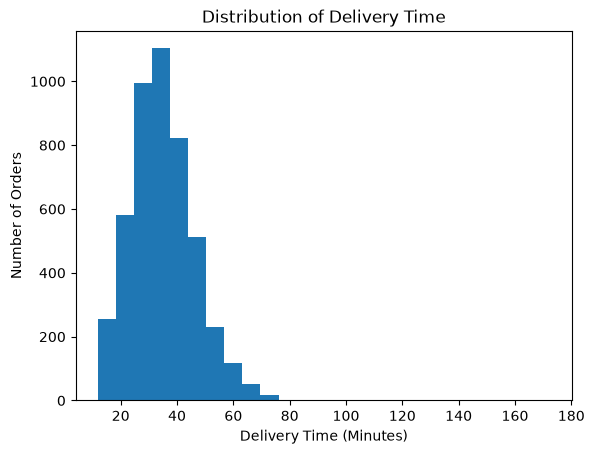

In [38]:
plt.hist(df["Delivery_Time_Min"], bins=25)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")
plt.show()

**Observation:**<br>
Most of the orders are delivered in 20 - 50mins.<br>
Highest number of orders are delivered between 30 - 40mins.<br>


# Distribution of Customer Ratings

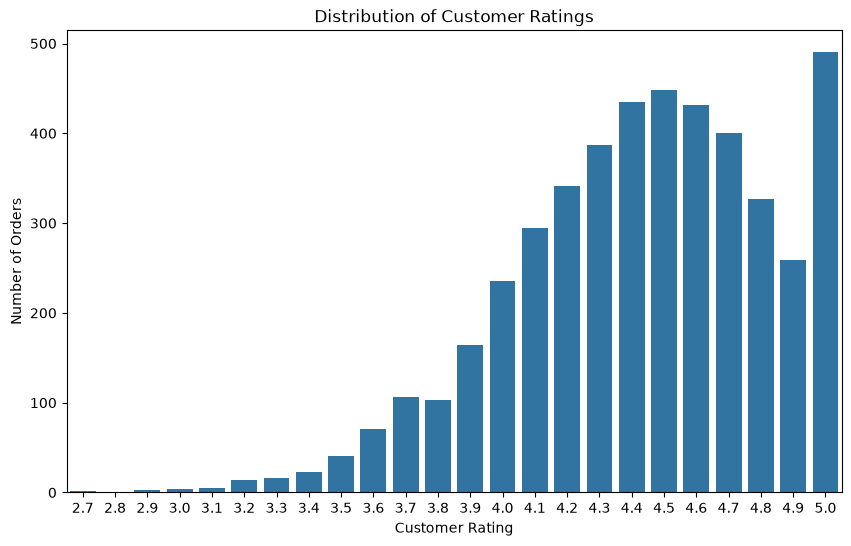

In [39]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Customer_Rating")
plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")
plt.show()

**Observation:**<br>
Most of the orders got ratings between 4 and 5.<br>
Very few customers gave rating below 3.8

# Orders By City

In [40]:
city_orders = df["City"].value_counts()

<BarContainer object of 5 artists>

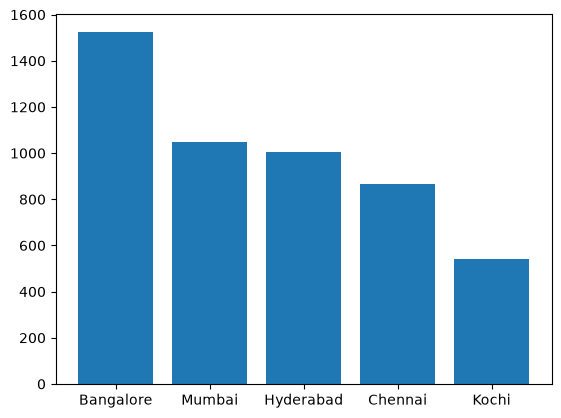

In [41]:
plt.bar(city_orders.index,city_orders.values)

**Observations.**<br>
Bangalore has highest orders with 1500 plus orders.<br>
kochi has less number of orders.

# Orders by Cuisine

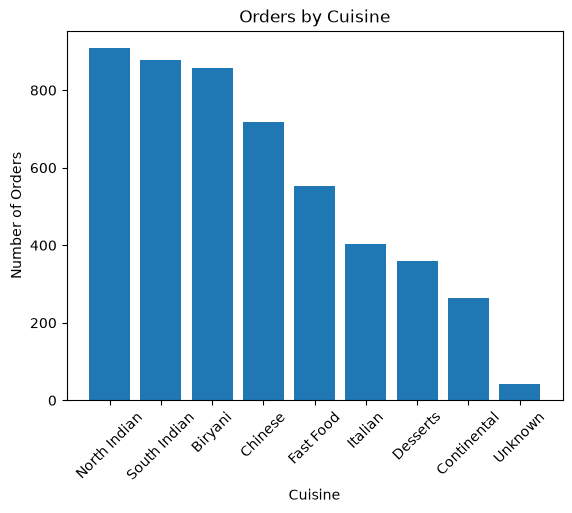

In [42]:
cuisine_counts = df["Cuisine"].value_counts()

plt.bar(cuisine_counts.index, cuisine_counts.values)

plt.title("Orders by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

**Observations.**<br>
North Indian, South Indian, Biryani are the most ordered cuisine.<br>
Italian, Dessers and continental are the least ordered cuisine


# Payment Method Usage

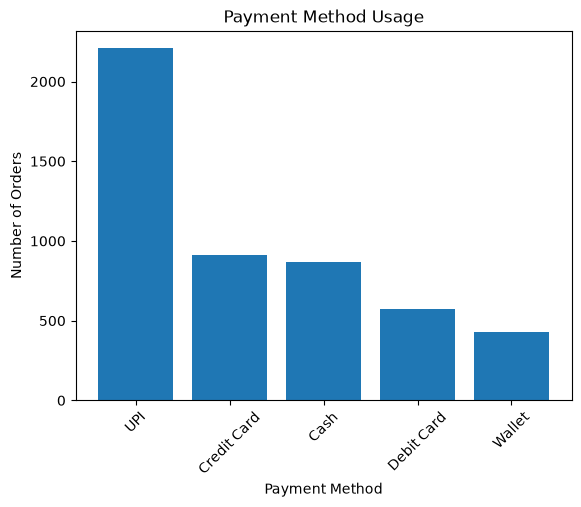

In [43]:
payment_counts = df["Payment_Method"].value_counts()

plt.bar(payment_counts.index, payment_counts.values)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

**Observations.**<br>
UPI is the most used payment method.<br>

# Orders Status Distribution

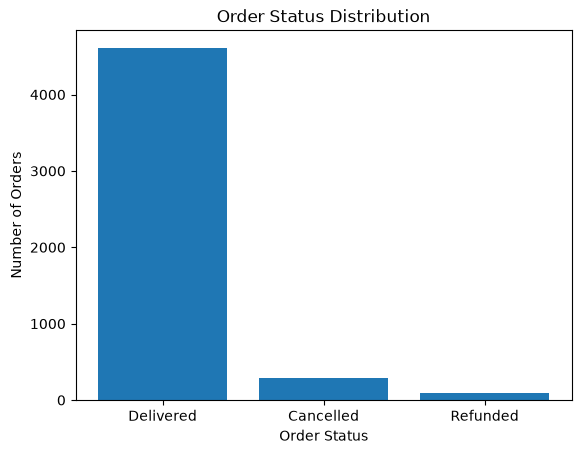

In [44]:
status_counts = df["Order_Status"].value_counts()

plt.bar(status_counts.index, status_counts.values)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

**Observations.**<br>
Order status of almost all the orders are delivered

# Outliers Analysis

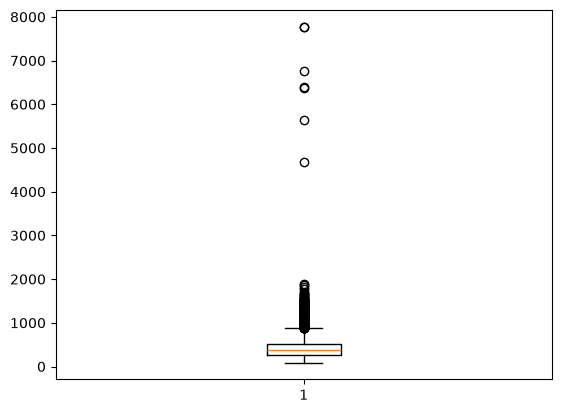

In [45]:
plt.boxplot(df["Order_Value"])
plt.show()

**Observations.**<br>
There are multiple outliers between order value 1000 and 2000.<br>
There are multiple outliers even above 5000

# Time Based Analysis

## Montly order dates

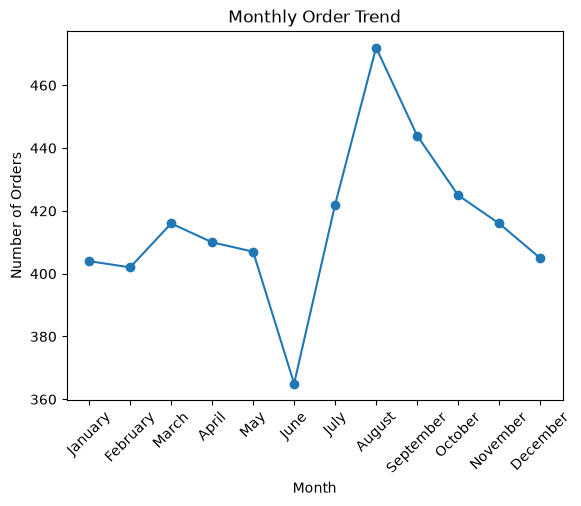

In [47]:
monthly_orders = df["Month"].value_counts().reindex(["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"])
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

**observation.**<br>
June month has the lowest number of orders and august month has highest number or orders.

# Orders by day of week

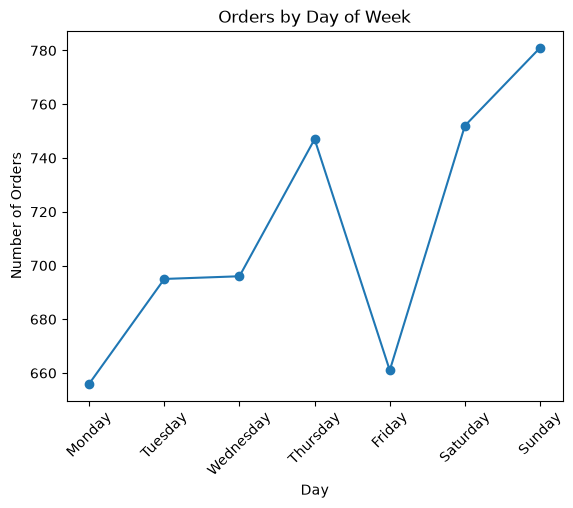

In [48]:
day_orders = df["Day"].value_counts().reindex( ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.plot(day_orders.index, day_orders.values,marker="o")
plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

**observation.**<br>
Monday and Friday got the least ordersr around 600 orders.<br> 
sunday got highest orders with around 800 orders.

# Orders by hour

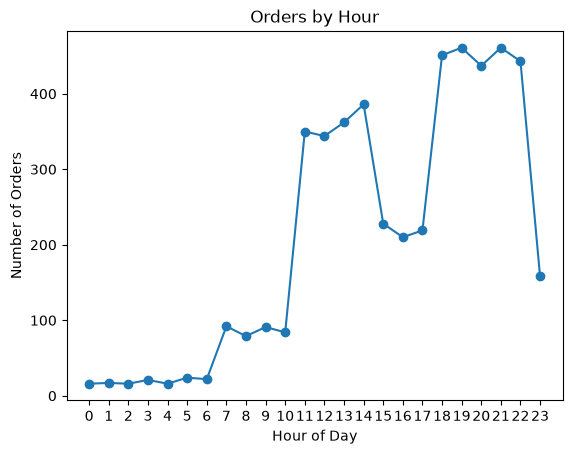

In [50]:
hourly_orders = df["Order_Hour"].value_counts().sort_index()
plt.plot(hourly_orders.index, hourly_orders.values, marker="o")
plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))
plt.show()

**observation.**<br>
Peak order hour is 6pm to 10pm.<br>
There are considerable orders between 11am to 2pm.

# Bivariate Analysis

## Distance vs Delivery Time

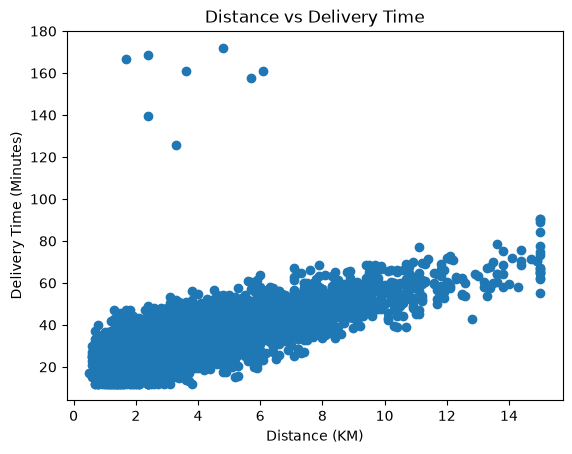

In [51]:
plt.scatter(df["Distance_KM"],df["Delivery_Time_Min"])
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (KM)")
plt.ylabel("Delivery Time (Minutes)")
plt.show()

**observation.**<br>
When the distance increases the delivery time increases.

# Delivery time vs Customer rating

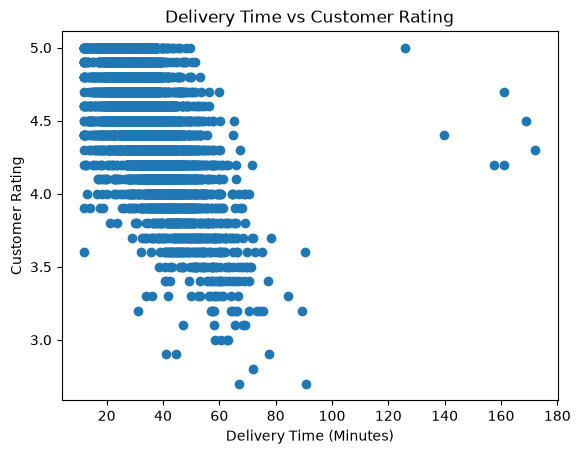

In [52]:
plt.scatter(df["Delivery_Time_Min"],df["Customer_Rating"])
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.show()

**observation.**<br>
When delivery time is increasing the customer rating is decreasing and when the delivery time is decreased the customer rating has been increased.

# Correlation Matrix

In [54]:
numeric_columns = ["Order_Value", "Delivery_Fee", "Delivery_Time_Min", "Distance_KM", "Customer_Rating"]
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,Order_Value,Delivery_Fee,Delivery_Time_Min,Distance_KM,Customer_Rating
Order_Value,1.000000,-0.165873,0.011584,0.004889,-0.007262
Delivery_Fee,-0.165873,1.000000,0.559486,0.804421,-0.410506
Delivery_Time_Min,0.011584,0.559486,1.000000,0.693296,-0.580728
Distance_KM,0.004889,0.804421,0.693296,1.000000,-0.506625
Customer_Rating,-0.007262,-0.410506,-0.580728,-0.506625,1.000000


<Axes: >

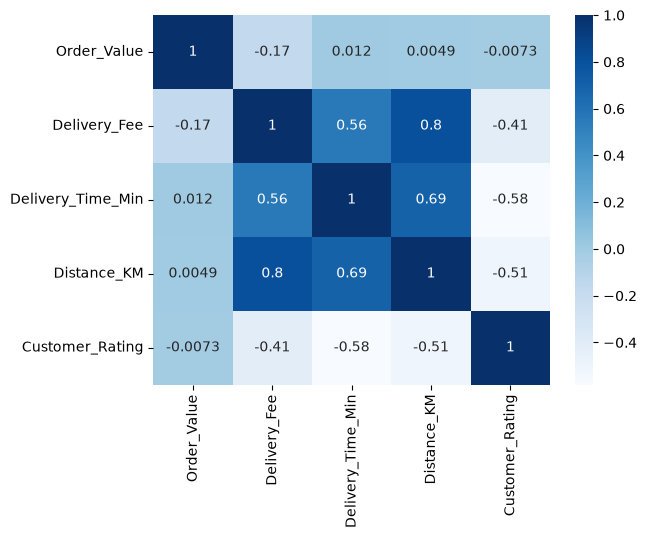

In [58]:
sns.heatmap(correlation_matrix,cmap="Blues",annot=True)


## Key Insights

### 1. Order Volume and Location

- After removing duplicate records, the dataset contains **4,988 unique orders**.
- **Bangalore recorded the highest number of orders (1,525)**, followed by Mumbai and Hyderabad.
- **Kochi recorded the lowest number of orders (543)**.
- Bangalore therefore represents the largest market in this dataset in terms of order volume.

### 2. Cuisine Preferences

- **North Indian cuisine was the most frequently ordered**, followed closely by South Indian and Biryani.
- Chinese and Fast Food also accounted for a considerable number of orders.
- Continental cuisine had comparatively lower demand.
- This indicates that Indian cuisines dominate customer preferences in the available order data.

### 3. Restaurant Type

- **Fast Food restaurants received the highest number of orders**, followed by Cloud Kitchens and Casual Dining restaurants.
- Fine Dining restaurants received the fewest orders.
- However, Fine Dining had a significantly higher **average order value of approximately ₹924**, compared with the other restaurant categories.
- This shows an important distinction between **order volume and order value**: a category receiving fewer orders can still generate high-value transactions.

### 4. Payment Preferences

- **UPI was the most commonly used payment method**, accounting for substantially more orders than any other payment option.
- Credit Card and Cash were the next most frequently used methods.
- Wallet was the least frequently used payment method.
- The analysis therefore shows a strong customer preference for digital payments, particularly UPI.

### 5. Order Timing

- Order activity was noticeably higher during **lunch and dinner hours**.
- The strongest concentration of orders occurred during the evening, particularly around **6 PM to 10 PM**.
- **7 PM and 9 PM recorded some of the highest hourly order volumes**.
- This suggests that dinner is a particularly important operating period for the business.

### 6. Weekly Ordering Pattern

- **Sunday recorded the highest number of orders**, followed by Saturday.
- Weekend demand was therefore noticeably strong.
- However, total weekday and weekend counts should not be directly compared without considering that there are five weekdays but only two weekend days.
- Average daily order volume provides a more appropriate comparison when evaluating weekday versus weekend demand.

### 7. Order Completion

- Approximately **92.4% of orders were successfully delivered**.
- Around **5.7% were cancelled**, while approximately **1.9% were refunded**.
- The majority of transactions therefore reached successful delivery, although cancelled and refunded orders still represent an area that can be investigated further.

### 8. Delivery Performance

- Average delivery time varied across cities.
- **Mumbai had the highest average delivery time at approximately 37 minutes**, closely followed by Bangalore.
- **Kochi had the lowest average delivery time at approximately 32 minutes**.
- The differences suggest that delivery performance may vary depending on location and operating conditions.

### 9. Distance and Delivery Time

- A clear positive relationship was observed between **delivery distance and delivery time**.
- The correlation between the two variables was approximately **0.69**.
- Longer-distance orders therefore generally required more time to deliver.
- However, the relationship was not perfect, indicating that factors other than distance also influence delivery time.

### 10. Delivery Distance and Delivery Fee

- Delivery distance showed a strong positive relationship with **delivery fee**, with a correlation of approximately **0.80**.
- This indicates that longer-distance orders generally attract higher delivery charges.
- Order value showed a slight negative relationship with delivery fee, which is consistent with some higher-value orders receiving reduced delivery charges.

### 11. Delivery Performance and Customer Satisfaction

- Delivery time showed a moderate negative relationship with **customer rating**, with a correlation of approximately **-0.58**.
- This means that as delivery time increases, customer ratings generally tend to decrease.
- Distance also had a negative relationship with ratings, which may partly occur because longer distances tend to result in longer delivery times.
- Delivery speed therefore appears to be an important factor associated with customer satisfaction.

### 12. Restaurant Type and Ratings

- Average customer ratings were relatively similar across restaurant types.
- No restaurant category showed an exceptionally large advantage in customer ratings.
- This suggests that restaurant type alone may not be a major factor determining customer satisfaction in this dataset.

## Business Recommendations

- Increase Delivery Capacity During Peak Hours
- Strengthen Weekend Operations
- Focus on High-Demand Cuisines
- Treat Fine Dining as a High-Value Segment
- Improve Delivery Performance in Slower Cities
- Pay Particular Attention to Long-Distance Orders
- Reduce Delivery Delays to Improve Customer Satisfaction
- Investigate Cancelled and Refunded Orders
- Maintain a Smooth UPI Payment Experience

## Conclusion

##### This project demonstrates a complete Exploratory Data Analysis workflow using Python. It covers data understanding, cleaning, feature engineering, univariate and bivariate analysis, outlier detection, correlation, visualization, insight generation, and business recommendations.

### Skills Demonstrated
`Python` • `Pandas` • `NumPy` • `Matplotlib` • `Seaborn` • `Data Cleaning` • `EDA` • `Data Visualization` • `Business Analysis`